<a href="https://colab.research.google.com/github/Jesse-Allister-Kasien-Elliott/asian-option-pricing-ml/blob/main/pricing_asian_options.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Asian options – the payoff and both analytical and numerical pricing methods



Firstly, know the different types of Asian options:

Arithmetic Asian
Geometric Asian

Discrete Asian
Contionuous Asian

Euro Asian
American Asian
Bermudan Asian


Numerical methods:
monte carlo
quasi-monte carlo
finite difference


Lower variance and thus lower pricing value.

Goal: price both geometric and arithmetic Asian options, then discuss alternative pricing and how good your method is that you chose

In [ ]:
######################################################################
# Pricing Vanilla Asian options with Monte carlo
######################################################################

In [ ]:
######################################################################
# Part 1: reduce the variance through antithetic variates
######################################################################

In [12]:
import numpy as np

In [2]:
# This first routine `mc_asian_basic` implements the crude Monte Carlo estimator.
# In the next cell, we include antithetic variates to reduce variance.

def mc_asian_basic(
    option_type,                                      # "call" or "put"
    average_type,                                     # "arithmetic" or "geometric"
    S0,                                               # initial asset price S_0
    K,                                                # strike price
    r,                                                # risk-free rate (drift + discounting)
    sigma,                                            # volatility
    T,                                                # maturity (years)
    N,                                                # number of Monte Carlo paths
    M,                                                # number of time steps (averaging points)
    random_seed                                       # RNG seed (reproducibility)
):
    rng = np.random.default_rng(random_seed)
    dt = T / M                                        # time step size Δt
    discounted_payoffs = []                           # stores e^{-rT} * payoff for each path

    for i in range(N):                                # Monte Carlo paths
        S = S0                                        # initialize S at time 0
        path_values = []                              # will store S_{t1},...,S_{tM}

        for j in range(M):                            # simulate path over time
            Z = rng.standard_normal()                 # Z ~ N(0,1)

            # GBM under risk-neutral measure:
            # S_{t+Δt} = S_t * exp((r - 1/2 σ^2)Δt + σ√Δt Z)
            S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

            path_values.append(S)                     # store price at this time step

        # compute average along path
        if average_type == "arithmetic":
            S_avg = sum(path_values) / M              # arithmetic mean: (1/M) Σ S_j

        elif average_type == "geometric":
            # geometric mean: exp((1/M) Σ log S_j) = (∏ S_j)^(1/M)
            # computed via logs for numerical stability
            S_avg = np.exp(np.mean(np.log(path_values)))

        else:
            raise ValueError("average_type must be 'arithmetic' or 'geometric'")

        # payoff based on path average
        if option_type == "call":
            payoff = max(S_avg - K, 0.0)
        elif option_type == "put":
            payoff = max(K - S_avg, 0.0)
        else:
            raise ValueError("option_type must be 'call' or 'put'")

        discounted_payoff = np.exp(-r * T) * payoff   # discount to time 0
        discounted_payoffs.append(discounted_payoff)

    price = np.mean(discounted_payoffs)               # MC estimator E[e^{-rT} payoff]

    # variance diagnostics
    sample_variance = np.var(discounted_payoffs, ddof=1)  # Var of simulated payoffs
    estimator_variance = sample_variance / N              # Var of MC estimator
    standard_error = np.sqrt(estimator_variance)          # std error of estimate

    return price, sample_variance, estimator_variance, standard_error

In [18]:
# This routine `mc_asian_antithetic` implements Monte Carlo with antithetic variates.
# Antithetic variates reduce variance by pairing Z and -Z to induce negative
# correlation between path payoffs, so their average has lower variance.
# Each sample uses a paired path: one with Z and the other with -Z.

def mc_asian_antithetic(
    option_type,                                                # "call" or "put"
    average_type,                                               # "arithmetic" or "geometric"
    S0,                                                         # initial asset price S_0
    K,                                                          # strike price
    r,                                                          # risk-free rate (drift + discounting)
    sigma,                                                      # volatility
    T,                                                          # maturity (years)
    N,                                                          # number of Monte Carlo paths
    M,                                                          # number of time steps (averaging points)
    random_seed                                                 # RNG seed (reproducibility)
):
    rng = np.random.default_rng(random_seed)
    dt = T / M                                                  # time step size Δt
    discounted_pair_payoffs = []                                # stores e^{-rT} * paired payoff

    num_pairs = N // 2                                          # each pair uses paths driven by Z and -Z

    for i in range(num_pairs):                                  # Monte Carlo path pairs
        Zs = rng.standard_normal(M)                             # shocks Z_1,...,Z_M for one path

        S_plus = S0                                             # path driven by Z
        S_minus = S0                                            # antithetic path driven by -Z

        path_plus = []                                          # stores S^+_{t1},...,S^+_{tM}
        path_minus = []                                         # stores S^-_{t1},...,S^-_{tM}

        for Z in Zs:                                            # simulate both paths over time
            # original GBM step using Z
            S_plus = S_plus * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

            # antithetic GBM step using -Z
            S_minus = S_minus * np.exp((r - 0.5 * sigma**2) * dt - sigma * np.sqrt(dt) * Z)

            path_plus.append(S_plus)                            # store original-path price
            path_minus.append(S_minus)                          # store antithetic-path price

        # compute averages along both paths
        if average_type == "arithmetic":
            avg_plus = sum(path_plus) / M                       # arithmetic mean for original path
            avg_minus = sum(path_minus) / M                     # arithmetic mean for antithetic path

        elif average_type == "geometric":
            # geometric mean: exp((1/M) Σ log S_j) = (∏ S_j)^(1/M)
            avg_plus = np.exp(np.mean(np.log(path_plus)))
            avg_minus = np.exp(np.mean(np.log(path_minus)))

        else:
            raise ValueError("average_type must be 'arithmetic' or 'geometric'")

        # payoff based on path averages
        if option_type == "call":
            payoff_plus = max(avg_plus - K, 0.0)
            payoff_minus = max(avg_minus - K, 0.0)
        elif option_type == "put":
            payoff_plus = max(K - avg_plus, 0.0)
            payoff_minus = max(K - avg_minus, 0.0)
        else:
            raise ValueError("option_type must be 'call' or 'put'")

        # average paired payoffs to reduce variance
        pair_payoff = 0.5 * (payoff_plus + payoff_minus)

        discounted_pair_payoff = np.exp(-r * T) * pair_payoff  # discount to time 0
        discounted_pair_payoffs.append(discounted_pair_payoff)

    price = np.mean(discounted_pair_payoffs)                   # antithetic MC estimator

    # variance diagnostics
    sample_variance = np.var(discounted_pair_payoffs, ddof=1)  # Var of paired samples
    estimator_variance = sample_variance / num_pairs           # Var of estimator
    standard_error = np.sqrt(estimator_variance)               # std error of estimate

    return price, sample_variance, estimator_variance, standard_error

In [10]:
# display option being priced
print(f"Option: {label}")

# display results for crude Monte Carlo
print("\nBasic Monte Carlo")
print("Price:", basic_price)                  # estimator of option price
print("Sample variance:", basic_sample_var)   # variance of simulated payoffs
print("Estimator variance:", basic_est_var)   # variance of MC estimator = Var/N
print("Standard error:", basic_se)            # sqrt(estimator variance)

# display results for antithetic variates
print("\nAntithetic Monte Carlo")
print("Price:", anti_price)
print("Sample variance:", anti_sample_var)
print("Estimator variance:", anti_est_var)
print("Standard error:", anti_se)

# compare variance reduction
ratio = anti_est_var / basic_est_var
reduction = 100 * (1 - ratio)

print("\nVariance reduction from antithetic variates")
print(f"Estimator variance ratio: {ratio:.3f}  (antithetic / basic)")
print(f"Variance reduced by: {reduction:.1f}%  (down to {100*ratio:.1f}% of original)")

Option: call Asian option (arithmetic average, European exercise)

Basic Monte Carlo
Price: 5.927152538433707
Sample variance: 65.19813306649982
Estimator variance: 0.0065198133066499825
Standard error: 0.08074536089862985

Antithetic Monte Carlo
Price: 5.888908141076436
Sample variance: 15.771972655026829
Estimator variance: 0.003154394531005366
Standard error: 0.05616399675063524

Variance reduction from antithetic variates
Estimator variance ratio: 0.484  (antithetic / basic)
Variance reduced by: 51.6%  (down to 48.4% of original)


In [ ]:
######################################################################
# Part 2: compare monte carlo with binomial
######################################################################

In [26]:
# This routine `mc_arithmetic_asian` computes the price of a European
# arithmetic Asian option using vectorized Monte Carlo with antithetic variates.
#
# Vectorization: instead of looping over paths and time steps in Python (slow),
# we operate on whole arrays using NumPy (C-level operations). This greatly
# improves efficiency by reducing Python overhead and leveraging optimized
# numerical routines.

def mc_arithmetic_asian(
    option_type,                                                # "call" or "put"
    S0,                                                         # initial asset price S_0
    K,                                                          # strike price
    r,                                                          # risk-free rate (drift + discounting)
    sigma,                                                      # volatility
    T,                                                          # maturity (years)
    num_paths,                                                  # number of Monte Carlo paths
    num_time_steps,                                             # number of time steps (averaging points)
    random_seed                                                 # RNG seed (reproducibility)
):
    rng = np.random.default_rng(random_seed)
    dt = T / num_time_steps                                     # time step size Δt
    num_pairs = num_paths // 2                                  # use pairs: Z and -Z

    # Generate all shocks at once: shape = (num_pairs, num_time_steps)
    Z = rng.standard_normal((num_pairs, num_time_steps))

    Z_plus = Z                                                  # original shocks
    Z_minus = -Z                                                # antithetic shocks

    drift = (r - 0.5 * sigma**2) * dt
    vol = sigma * np.sqrt(dt)

    log_increments_plus = drift + vol * Z_plus
    log_increments_minus = drift + vol * Z_minus

    log_paths_plus = np.cumsum(log_increments_plus, axis=1)
    log_paths_minus = np.cumsum(log_increments_minus, axis=1)

    S_paths_plus = S0 * np.exp(log_paths_plus)
    S_paths_minus = S0 * np.exp(log_paths_minus)

    avg_plus = np.mean(S_paths_plus, axis=1)
    avg_minus = np.mean(S_paths_minus, axis=1)

    if option_type == "call":
        payoff_plus = np.maximum(avg_plus - K, 0.0)
        payoff_minus = np.maximum(avg_minus - K, 0.0)
    elif option_type == "put":
        payoff_plus = np.maximum(K - avg_plus, 0.0)
        payoff_minus = np.maximum(K - avg_minus, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    pair_payoffs = 0.5 * (payoff_plus + payoff_minus)

    discounted_pair_payoffs = np.exp(-r * T) * pair_payoffs
    price = np.mean(discounted_pair_payoffs)

    return price

In [27]:
# This routine `binomial_arithmetic_asian` computes the price of a European
# arithmetic Asian option by brute-force enumeration of all binomial paths.
#
# Note: num_time_steps controls both time discretization and averaging resolution.
# Cost grows exponentially: O(2^{num_time_steps}).

def binomial_arithmetic_asian(
    option_type,                                      # "call" or "put"
    S0,                                               # initial asset price S_0
    K,                                                # strike price
    r,                                                # risk-free rate
    sigma,                                            # volatility
    T,                                                # maturity (years)
    num_time_steps                                    # number of time steps (and averaging points)
):
    dt = T / num_time_steps                           # time step size Δt

    u = np.exp(sigma * np.sqrt(dt))                   # up factor
    d = 1 / u                                         # down factor
    p = (np.exp(r * dt) - d) / (u - d)                # risk-neutral up probability

    price_sum = 0.0                                   # expected payoff accumulator

    for path in range(2**num_time_steps):             # enumerate all paths
        S = S0
        path_sum = 0.0                                # running sum for arithmetic average
        prob = 1.0

        for i in range(num_time_steps):               # build one path
            if (path >> i) & 1:                       # up move
                S *= u
                prob *= p
            else:                                     # down move
                S *= d
                prob *= (1 - p)

            path_sum += S                             # accumulate S values

        A = path_sum / num_time_steps                 # arithmetic average

        if option_type == "call":
            payoff = max(A - K, 0.0)
        elif option_type == "put":
            payoff = max(K - A, 0.0)
        else:
            raise ValueError("option_type must be 'call' or 'put'")

        price_sum += prob * payoff

    price = np.exp(-r * T) * price_sum

    return price

In [31]:
import time

# compare Monte Carlo vs Binomial
# European arithmetic Asian call/put

# shared model parameters
S0 = 100.0                         # initial asset price
K = 100.0                          # strike price
r = 0.05                           # risk-free rate
sigma = 0.2                        # volatility
T = 1.0                            # maturity (years)

# Monte Carlo parameters
num_time_steps_mc = 20             # MC averaging points
num_paths_ref = 1_000_000          # large MC sample for reference price
num_paths_mc = 200_000             # MC paths for ordinary comparison

# Binomial parameters
num_time_steps_binomial = 20       # binomial time steps; cost = O(2^num_time_steps)

random_seed = 0                    # RNG seed

# Monte Carlo reference price
start = time.time()
ref_call = mc_arithmetic_asian("call", S0, K, r, sigma, T, num_paths_ref, num_time_steps_mc, random_seed)
ref_call_time = time.time() - start

start = time.time()
ref_put = mc_arithmetic_asian("put", S0, K, r, sigma, T, num_paths_ref, num_time_steps_mc, random_seed)
ref_put_time = time.time() - start

# Monte Carlo with antithetic variates
start = time.time()
mc_call = mc_arithmetic_asian("call", S0, K, r, sigma, T, num_paths_mc, num_time_steps_mc, random_seed)
mc_call_time = time.time() - start

start = time.time()
mc_put = mc_arithmetic_asian("put", S0, K, r, sigma, T, num_paths_mc, num_time_steps_mc, random_seed)
mc_put_time = time.time() - start

# binomial path enumeration
start = time.time()
bin_call = binomial_arithmetic_asian("call", S0, K, r, sigma, T, num_time_steps_binomial)
bin_call_time = time.time() - start

start = time.time()
bin_put = binomial_arithmetic_asian("put", S0, K, r, sigma, T, num_time_steps_binomial)
bin_put_time = time.time() - start

# errors relative to Monte Carlo reference
mc_call_error = abs(mc_call - ref_call)
mc_put_error = abs(mc_put - ref_put)

bin_call_error = abs(bin_call - ref_call)
bin_put_error = abs(bin_put - ref_put)

# output
print("European arithmetic Asian option")
print(f"Model parameters: S0={S0}, K={K}, r={r}, sigma={sigma}, T={T}")

print("\n---- Monte Carlo Reference ----")
print(f"Parameters: num_paths={num_paths_ref}, num_time_steps={num_time_steps_mc}, antithetic=True")
print(f"Call reference: {ref_call:.6f}   time: {ref_call_time:.4f}s")
print(f"Put  reference: {ref_put:.6f}   time: {ref_put_time:.4f}s")

print("\n---- Monte Carlo Antithetic ----")
print(f"Parameters: num_paths={num_paths_mc}, num_time_steps={num_time_steps_mc}, antithetic=True")
print(f"Call: {mc_call:.6f}   error: {mc_call_error:.6f}   time: {mc_call_time:.4f}s")
print(f"Put : {mc_put:.6f}   error: {mc_put_error:.6f}   time: {mc_put_time:.4f}s")

print("\n---- Binomial Path Enumeration ----")
print(f"Parameters: num_time_steps={num_time_steps_binomial}, paths=2^{num_time_steps_binomial}={2**num_time_steps_binomial}")
print(f"Call: {bin_call:.6f}   error: {bin_call_error:.6f}   time: {bin_call_time:.4f}s")
print(f"Put : {bin_put:.6f}   error: {bin_put_error:.6f}   time: {bin_put_time:.4f}s")

European arithmetic Asian option
Model parameters: S0=100.0, K=100.0, r=0.05, sigma=0.2, T=1.0

---- Monte Carlo Reference ----
Parameters: num_paths=1000000, num_time_steps=20, antithetic=True
Call reference: 6.000158   time: 0.6476s
Put  reference: 3.459809   time: 0.6481s

---- Monte Carlo Antithetic ----
Parameters: num_paths=200000, num_time_steps=20, antithetic=True
Call: 6.004657   error: 0.004499   time: 0.1366s
Put : 3.462619   error: 0.002810   time: 0.1329s

---- Binomial Path Enumeration ----
Parameters: num_time_steps=20, paths=2^20=1048576
Call: 6.029008   error: 0.028850   time: 7.6833s
Put : 3.488822   error: 0.029013   time: 7.7537s


In [24]:
# -----------------------------
# CONVERGENCE CHECK: MONTE CARLO
# -----------------------------
print("\n---- Monte Carlo convergence ----")

for N_test in [10_000, 50_000, 200_000, 1_000_000]:

    start = time.time()
    mc_call_test = mc_arithmetic_asian("call", S0, K, r, sigma, T, N_test, M_mc, random_seed)
    call_time = time.time() - start

    start = time.time()
    mc_put_test = mc_arithmetic_asian("put", S0, K, r, sigma, T, N_test, M_mc, random_seed)
    put_time = time.time() - start

    call_error = abs(mc_call_test - ref_call)
    put_error = abs(mc_put_test - ref_put)

    print(
        f"N={N_test:>8} | "
        f"Call={mc_call_test:.6f} (err={call_error:.6f}, t={call_time:.2f}s) | "
        f"Put={mc_put_test:.6f} (err={put_error:.6f}, t={put_time:.2f}s)"
    )


---- Monte Carlo convergence ----
N=   10000 | Call=5.888908 (err=0.033430, t=0.03s) | Put=3.415659 (err=0.026304, t=0.03s)
N=   50000 | Call=5.851152 (err=0.004327, t=0.10s) | Put=3.392451 (err=0.003096, t=0.08s)
N=  200000 | Call=5.851877 (err=0.003602, t=0.31s) | Put=3.388306 (err=0.001049, t=0.34s)
N= 1000000 | Call=5.855479 (err=0.000000, t=1.55s) | Put=3.389355 (err=0.000000, t=1.52s)


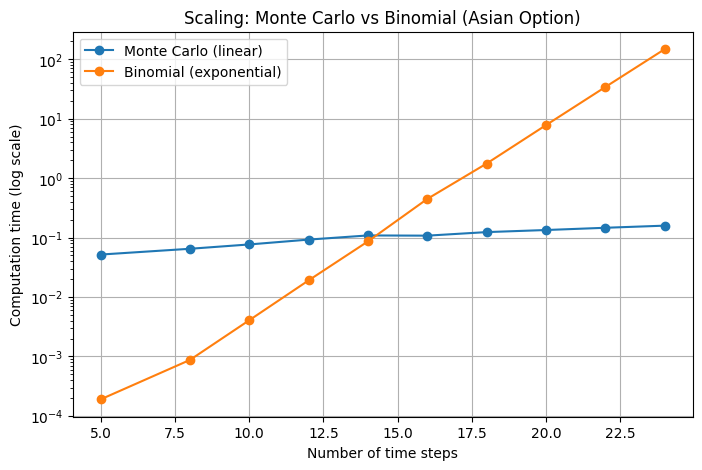

In [33]:
import time
import matplotlib.pyplot as plt

# range of time steps (keep modest or binomial explodes)
time_steps_list = [5, 8, 10, 12, 14, 16, 18, 20, 22, 24]

mc_times = []
bin_times = []

num_paths = 200_000  # fixed MC effort

for m in time_steps_list:

    # Monte Carlo timing
    start = time.time()
    mc_arithmetic_asian("call", S0, K, r, sigma, T, num_paths, m, random_seed)
    mc_times.append(time.time() - start)

    # Binomial timing
    start = time.time()
    binomial_arithmetic_asian("call", S0, K, r, sigma, T, m)
    bin_times.append(time.time() - start)

# plot
plt.figure(figsize=(8,5))

plt.plot(time_steps_list, mc_times, 'o-', label='Monte Carlo (linear)')
plt.plot(time_steps_list, bin_times, 'o-', label='Binomial (exponential)')

plt.yscale("log")  # critical: reveals exponential growth clearly

plt.xlabel("Number of time steps")
plt.ylabel("Computation time (log scale)")
plt.title("Scaling: Monte Carlo vs Binomial (Asian Option)")
plt.legend()
plt.grid()

plt.show()

In [ ]:
######################################################################
# Part 3: Geometric Asian
# A geometric Asian option is priced analytically by noting that the geometric average is lognormal,
# allowing a Black–Scholes-type closed-form formula with adjusted mean and variance.
######################################################################



In [34]:
from math import exp, log, sqrt
from scipy.stats import norm

# Analytic price for a European geometric Asian option under GBM.
# Uses M equally spaced averaging dates: t_1,...,t_M, excluding S_0.

def analytic_geometric_asian(
    option_type,                                                # "call" or "put"
    S0,                                                         # initial asset price S_0
    K,                                                          # strike price
    r,                                                          # risk-free rate
    sigma,                                                      # volatility
    T,                                                          # maturity (years)
    M                                                          # number of averaging dates
):
    # log geometric average is normally distributed:
    # log(G) ~ Normal(mu_G, var_G)

    mu_G = log(S0) + (r - 0.5 * sigma**2) * T * (M + 1) / (2 * M)

    var_G = sigma**2 * T * (M + 1) * (2 * M + 1) / (6 * M**2)

    sigma_G = sqrt(var_G)

    d1 = (mu_G - log(K) + var_G) / sigma_G
    d2 = d1 - sigma_G

    discounted = exp(-r * T)

    if option_type == "call":
        price = discounted * (exp(mu_G + 0.5 * var_G) * norm.cdf(d1) - K * norm.cdf(d2))

    elif option_type == "put":
        price = discounted * (K * norm.cdf(-d2) - exp(mu_G + 0.5 * var_G) * norm.cdf(-d1))

    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price

In [38]:
import time

# -----------------------------
# VALIDATION: Geometric Asian option
# Same option, different pricing methods:
# closed-form formula vs Monte Carlo approximation
# -----------------------------

# parameters
num_paths_test = 500_000
num_time_steps = M  # same averaging dates used in closed-form formula and MC

# closed-form geometric Asian prices + timing
start = time.time()
geo_call_analytic = analytic_geometric_asian("call", S0, K, r, sigma, T, num_time_steps)
geo_call_analytic_time = time.time() - start

start = time.time()
geo_put_analytic = analytic_geometric_asian("put", S0, K, r, sigma, T, num_time_steps)
geo_put_analytic_time = time.time() - start

# Monte Carlo geometric Asian prices + timing
start = time.time()
geo_call_mc = mc_asian_basic("call", "geometric", S0, K, r, sigma, T, num_paths_test, num_time_steps, 0)[0]
geo_call_mc_time = time.time() - start

start = time.time()
geo_put_mc = mc_asian_basic("put", "geometric", S0, K, r, sigma, T, num_paths_test, num_time_steps, 0)[0]
geo_put_mc_time = time.time() - start

# errors relative to closed-form geometric Asian prices
call_error = abs(geo_call_mc - geo_call_analytic)
put_error = abs(geo_put_mc - geo_put_analytic)

# output
print("Geometric Asian option: closed-form vs Monte Carlo")
print(f"Parameters: num_paths={num_paths_test}, num_time_steps={num_time_steps}")

print("\nClosed-form geometric Asian")
print(f"Call: {geo_call_analytic:.6f}   time: {geo_call_analytic_time:.6f}s")
print(f"Put : {geo_put_analytic:.6f}   time: {geo_put_analytic_time:.6f}s")

print("\nMonte Carlo geometric Asian")
print(f"Call: {geo_call_mc:.6f}   error: {call_error:.6f}   time: {geo_call_mc_time:.4f}s")
print(f"Put : {geo_put_mc:.6f}   error: {put_error:.6f}   time: {geo_put_mc_time:.4f}s")

Geometric Asian option: closed-form vs Monte Carlo
Parameters: num_paths=500000, num_time_steps=20

Closed-form geometric Asian
Call: 5.782616   time: 0.000924s
Put : 3.576734   time: 0.000646s

Monte Carlo geometric Asian
Call: 5.776011   error: 0.006606   time: 39.1960s
Put : 3.582481   error: 0.005747   time: 38.8635s


In [ ]:
# Notice that closed form is much faster
#
# Closed-form:
# O(1)   (constant time)

# Monte Carlo:
# O(num_paths × num_time_steps)

In [ ]:
######################################################################
# Part 4: Pricing Asian options with ML
######################################################################

In [39]:
import numpy as np

# -----------------------------
# DATA GENERATION (training set)
# -----------------------------

def generate_asian_dataset(
    num_samples,                          # number of training examples
    num_paths,                            # MC paths (accuracy of labels)
    num_time_steps,                       # averaging points
    random_seed=0
):
    rng = np.random.default_rng(random_seed)

    X = []   # features
    y = []   # prices

    for _ in range(num_samples):

        # sample parameters (reasonable ranges)
        S0 = rng.uniform(80, 120)
        K = rng.uniform(80, 120)
        r = rng.uniform(0.01, 0.05)
        sigma = rng.uniform(0.1, 0.4)
        T = rng.uniform(0.5, 2.0)

        # MC price (label)
        price = mc_arithmetic_asian(
            "call", S0, K, r, sigma, T,
            num_paths, num_time_steps, random_seed
        )

        X.append([S0, K, r, sigma, T])
        y.append(price)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# generate dataset
num_samples = 2000
num_paths_label = 50_000   # smaller than reference, but ok for training
num_time_steps = 20

X, y = generate_asian_dataset(num_samples, num_paths_label, num_time_steps)

print("Dataset generated")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset generated
X shape: (2000, 5)
y shape: (2000,)


In [54]:
# NN model

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np

# -----------------------------
# TRAIN PYTORCH MODEL
# with input normalization, target normalization, and improved features
# -----------------------------

torch.manual_seed(0)

# -----------------------------
# FEATURE ENGINEERING
# -----------------------------
# Original inputs are:
# X = [S0, K, r, sigma, T]
#
# Add useful scale-free features:
# S0/K captures moneyness.
# log(S0/K) captures log-moneyness.
# These help the NN learn option-pricing structure more easily.

S0_col = X[:, 0]
K_col = X[:, 1]

moneyness = (S0_col / K_col).reshape(-1, 1)
log_moneyness = np.log(S0_col / K_col).reshape(-1, 1)

X_features = np.column_stack([
    X,                 # original 5 features: S0, K, r, sigma, T
    moneyness,         # S0 / K
    log_moneyness      # log(S0 / K)
]).astype(np.float32)

# -----------------------------
# INPUT NORMALIZATION
# -----------------------------
# Standardize each input feature:
# X_norm = (X - mean) / std
# This puts all features on comparable scale.

X_mean = X_features.mean(axis=0)
X_std = X_features.std(axis=0)
X_std[X_std == 0] = 1.0

X_normalized = (X_features - X_mean) / X_std

# -----------------------------
# TARGET NORMALIZATION
# -----------------------------
# Normalize option prices too:
# y_norm = (y - mean) / std
# This makes the regression target easier for the NN to learn.

y_mean = y.mean()
y_std = y.std()
if y_std == 0:
    y_std = 1.0

y_normalized = (y - y_mean) / y_std

# convert to tensors
X_tensor = torch.tensor(X_normalized, dtype=torch.float32)
y_tensor = torch.tensor(y_normalized, dtype=torch.float32).view(-1, 1)

# -----------------------------
# TRAIN / TEST SPLIT
# -----------------------------
dataset = TensorDataset(X_tensor, y_tensor)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# -----------------------------
# MODEL
# -----------------------------
class AsianPriceMLP(nn.Module):
    def __init__(self):
        super().__init__()

        # f(x) = W4 · ReLU(W3 · ReLU(W2 · ReLU(W1 · x + b1) + b2) + b3) + b4
        # [S0, K, r, sigma, T, S0/K, log(S0/K)]
        self.net = nn.Sequential(
            nn.Linear(7, 128),     # input layer: 7 features → 128 hidden units
            nn.ReLU(),             # nonlinearity
            nn.Linear(128, 128),   # hidden layer
            nn.ReLU(),             # nonlinearity
            nn.Linear(128, 64),    # hidden layer
            nn.ReLU(),             # nonlinearity
            nn.Linear(64, 1)       # output: normalized option price
        )

    def forward(self, x):
        return self.net(x)

model = AsianPriceMLP()

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 300

# -----------------------------
# TRAINING LOOP
# -----------------------------
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(X_batch)

    train_loss /= train_size

    # evaluation
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)
            test_loss += loss.item() * len(X_batch)

    test_loss /= test_size

    if epoch % 25 == 0 or epoch == num_epochs - 1:
        # convert normalized MSE back to price-scale RMSE
        train_rmse_price = np.sqrt(train_loss) * y_std
        test_rmse_price = np.sqrt(test_loss) * y_std

        print(
            f"Epoch {epoch:3d} | "
            f"train MSE(norm): {train_loss:.6f} | "
            f"test MSE(norm): {test_loss:.6f} | "
            f"test RMSE(price): {test_rmse_price:.6f}"
        )

Epoch   0 | train MSE(norm): 0.399819 | test MSE(norm): 0.047185 | test RMSE(price): 2.051541
Epoch  25 | train MSE(norm): 0.000335 | test MSE(norm): 0.000439 | test RMSE(price): 0.197869
Epoch  50 | train MSE(norm): 0.000150 | test MSE(norm): 0.000266 | test RMSE(price): 0.153933
Epoch  75 | train MSE(norm): 0.000130 | test MSE(norm): 0.000228 | test RMSE(price): 0.142558
Epoch 100 | train MSE(norm): 0.000044 | test MSE(norm): 0.000140 | test RMSE(price): 0.111635
Epoch 125 | train MSE(norm): 0.000060 | test MSE(norm): 0.000171 | test RMSE(price): 0.123548
Epoch 150 | train MSE(norm): 0.000841 | test MSE(norm): 0.000864 | test RMSE(price): 0.277687
Epoch 175 | train MSE(norm): 0.000040 | test MSE(norm): 0.000138 | test RMSE(price): 0.111053
Epoch 200 | train MSE(norm): 0.000086 | test MSE(norm): 0.000163 | test RMSE(price): 0.120600
Epoch 225 | train MSE(norm): 0.000339 | test MSE(norm): 0.000226 | test RMSE(price): 0.142025
Epoch 250 | train MSE(norm): 0.000068 | test MSE(norm): 0.00

In [58]:


import time
import numpy as np
import torch

# -----------------------------
# COMPARE: Neural Network vs Monte Carlo as MC paths increase
# -----------------------------

# option parameters
S0_test = 100.0
K_test = 100.0
r_test = 0.05
sigma_test = 0.2
T_test = 1.0

num_time_steps_compare = 20
random_seed = 0

mc_path_list = [50_000, 200_000, 1_000_000, 2_000_000]

# neural network prediction + timing
# NN was trained on 7 features:
# [S0, K, r, sigma, T, S0/K, log(S0/K)]
moneyness = S0_test / K_test
log_moneyness = np.log(S0_test / K_test)

x_new_features = np.array(
    [[S0_test, K_test, r_test, sigma_test, T_test, moneyness, log_moneyness]],
    dtype=np.float32
)

# use same input normalization from training
x_new_normalized = (x_new_features - X_mean) / X_std
x_new_tensor = torch.tensor(x_new_normalized, dtype=torch.float32)

model.eval()

start = time.time()
with torch.no_grad():
    nn_price_normalized = model(x_new_tensor).item()

# undo target normalization
nn_price = nn_price_normalized * y_std + y_mean
nn_time = time.time() - start

print("Neural Network vs Monte Carlo")
print("European arithmetic Asian call option")
print(f"Parameters: S0={S0_test}, K={K_test}, r={r_test}, sigma={sigma_test}, T={T_test}")
print(f"NN price: {nn_price:.6f}   NN time: {nn_time:.8f}s")

print("\nMonte Carlo comparison")
for num_paths_compare in mc_path_list:
    start = time.time()
    mc_price = mc_arithmetic_asian(
        "call",
        S0_test, K_test, r_test, sigma_test, T_test,
        num_paths_compare,
        num_time_steps_compare,
        random_seed
    )
    mc_time = time.time() - start

    error_vs_mc = abs(nn_price - mc_price)
    speedup = mc_time / nn_time

    print(
        f"MC paths={num_paths_compare:>9} | "
        f"MC price={mc_price:.6f} | "
        f"error={error_vs_mc:.6f} | "
        f"MC time={mc_time:.4f}s | "
        f"NN faster by {speedup:,.0f}x"
    )

Neural Network vs Monte Carlo
European arithmetic Asian call option
Parameters: S0=100.0, K=100.0, r=0.05, sigma=0.2, T=1.0
NN price: 6.017999   NN time: 0.00121880s

Monte Carlo comparison
MC paths=    50000 | MC price=6.039746 | error=0.021747 | MC time=0.0463s | NN faster by 38x
MC paths=   200000 | MC price=6.004657 | error=0.013342 | MC time=0.1347s | NN faster by 111x
MC paths=  1000000 | MC price=6.000158 | error=0.017841 | MC time=0.6762s | NN faster by 555x
MC paths=  2000000 | MC price=6.002718 | error=0.015281 | MC time=1.2626s | NN faster by 1,036x


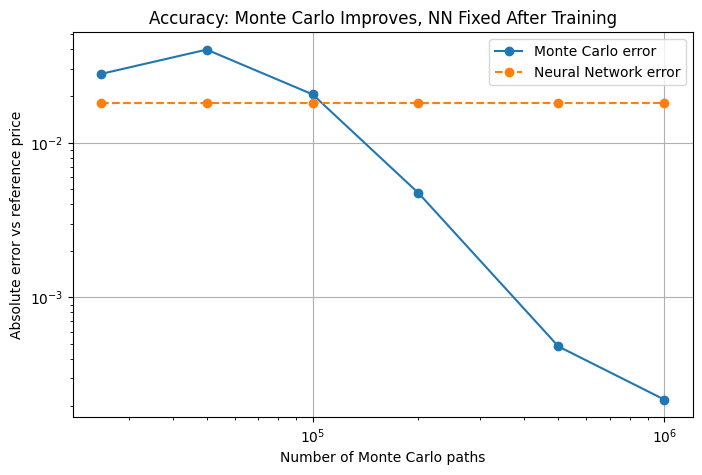

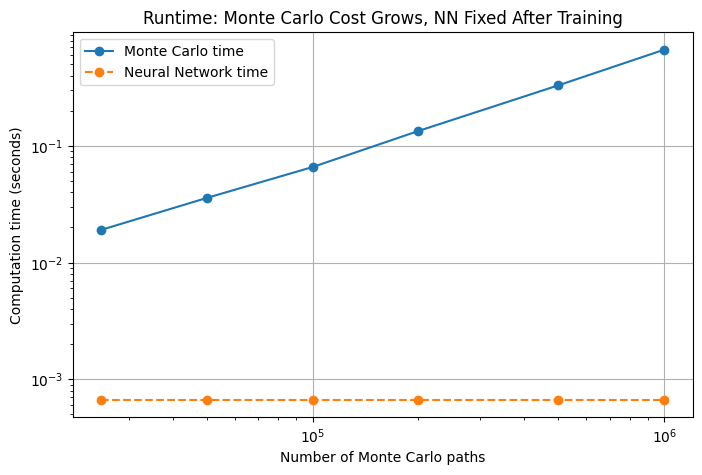

Accuracy-time comparison
Reference price: 5.999939  (paths=3000000, time=1.9503s)
NN price:        6.017999  error=0.018060, time=0.00066876s

Monte Carlo results
paths=    25000 | error=0.027717 | time=0.0190s | MC/NN time ratio=28x
paths=    50000 | error=0.039807 | time=0.0358s | MC/NN time ratio=54x
paths=   100000 | error=0.020470 | time=0.0659s | MC/NN time ratio=99x
paths=   200000 | error=0.004718 | time=0.1344s | MC/NN time ratio=201x
paths=   500000 | error=0.000482 | time=0.3310s | MC/NN time ratio=495x
paths=  1000000 | error=0.000219 | time=0.6693s | MC/NN time ratio=1,001x


In [59]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# PLOT: Accuracy-Time Tradeoff
# Monte Carlo vs Neural Network
# -----------------------------

# option parameters
S0_test = 100.0
K_test = 100.0
r_test = 0.05
sigma_test = 0.2
T_test = 1.0

num_time_steps_compare = 20
random_seed = 0

mc_path_list = [25_000, 50_000, 100_000, 200_000, 500_000, 1_000_000]

# high-sample MC reference price
num_paths_reference = 3_000_000

start = time.time()
reference_price = mc_arithmetic_asian(
    "call",
    S0_test, K_test, r_test, sigma_test, T_test,
    num_paths_reference,
    num_time_steps_compare,
    random_seed
)
reference_time = time.time() - start

# -----------------------------
# NN prediction setup
# -----------------------------
# New NN uses 7 features:
# [S0, K, r, sigma, T, S0/K, log(S0/K)]

moneyness = S0_test / K_test
log_moneyness = np.log(S0_test / K_test)

x_new_features = np.array(
    [[S0_test, K_test, r_test, sigma_test, T_test, moneyness, log_moneyness]],
    dtype=np.float32
)

# use same input normalization from training
x_new_normalized = (x_new_features - X_mean) / X_std
x_new_tensor = torch.tensor(x_new_normalized, dtype=torch.float32)

model.eval()

start = time.time()
with torch.no_grad():
    nn_price_normalized = model(x_new_tensor).item()

# undo target normalization
nn_price = nn_price_normalized * y_std + y_mean
nn_time = time.time() - start

nn_error = abs(nn_price - reference_price)

# -----------------------------
# Monte Carlo results
# -----------------------------
mc_times = []
mc_errors = []

for num_paths in mc_path_list:
    start = time.time()
    mc_price = mc_arithmetic_asian(
        "call",
        S0_test, K_test, r_test, sigma_test, T_test,
        num_paths,
        num_time_steps_compare,
        random_seed
    )
    mc_time = time.time() - start
    mc_error = abs(mc_price - reference_price)

    mc_times.append(mc_time)
    mc_errors.append(mc_error)

# constant NN lines
nn_times = [nn_time] * len(mc_path_list)
nn_errors = [nn_error] * len(mc_path_list)

# -----------------------------
# PLOT 1: Error vs MC paths
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(mc_path_list, mc_errors, 'o-', label='Monte Carlo error')
plt.plot(mc_path_list, nn_errors, 'o--', label='Neural Network error')

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of Monte Carlo paths")
plt.ylabel("Error")
plt.title("Accuracy: Monte Carlo Improves, NN Fixed After Training")

plt.legend()
plt.grid()
plt.show()

# -----------------------------
# PLOT 2: Time vs MC paths
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(mc_path_list, mc_times, 'o-', label='Monte Carlo time')
plt.plot(mc_path_list, nn_times, 'o--', label='Neural Network time')

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of Monte Carlo paths")
plt.ylabel("Computation time (seconds)")
plt.title("Runtime: Monte Carlo Cost Grows, NN Fixed After Training")

plt.legend()
plt.grid()
plt.show()

# -----------------------------
# OUTPUT SUMMARY
# -----------------------------
print("Accuracy-time comparison")
print(f"Reference price: {reference_price:.6f}  (paths={num_paths_reference}, time={reference_time:.4f}s)")
print(f"NN price:        {nn_price:.6f}  error={nn_error:.6f}, time={nn_time:.8f}s")

print("\nMonte Carlo results")
for num_paths, mc_time, mc_error in zip(mc_path_list, mc_times, mc_errors):
    print(
        f"paths={num_paths:>9} | "
        f"error={mc_error:.6f} | "
        f"time={mc_time:.4f}s | "
        f"MC/NN time ratio={mc_time / nn_time:,.0f}x"
    )